In [6]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [16]:
def create_oracle(targets, n):
    """Flips the phase of marked states using Qiskit gates[cite: 23]."""
    oracle_qc = QuantumCircuit(n)
    for target in targets:
        for i, bit in enumerate(reversed(target)):
            if bit == '0': oracle_qc.x(i)
        oracle_qc.h(n-1)
        oracle_qc.mcx(list(range(n-1)), n-1) # Multi-controlled phase flip [cite: 31]
        oracle_qc.h(n-1)
        for i, bit in enumerate(reversed(target)):
            if bit == '1' if bit == '0' else '0': pass # Logic to restore state
            if bit == '0': oracle_qc.x(i)
    return oracle_qc.to_gate(label="Oracle")

In [17]:
def create_diffusion(n):
    """Implements the H -> U0 -> H diffusion operator[cite: 28]."""
    qc = QuantumCircuit(n)
    qc.h(range(n)) 
    qc.x(range(n)) # U0 phase flip [cite: 29]
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc.to_gate(label="Diffusion")

--- 1 Iterations ---


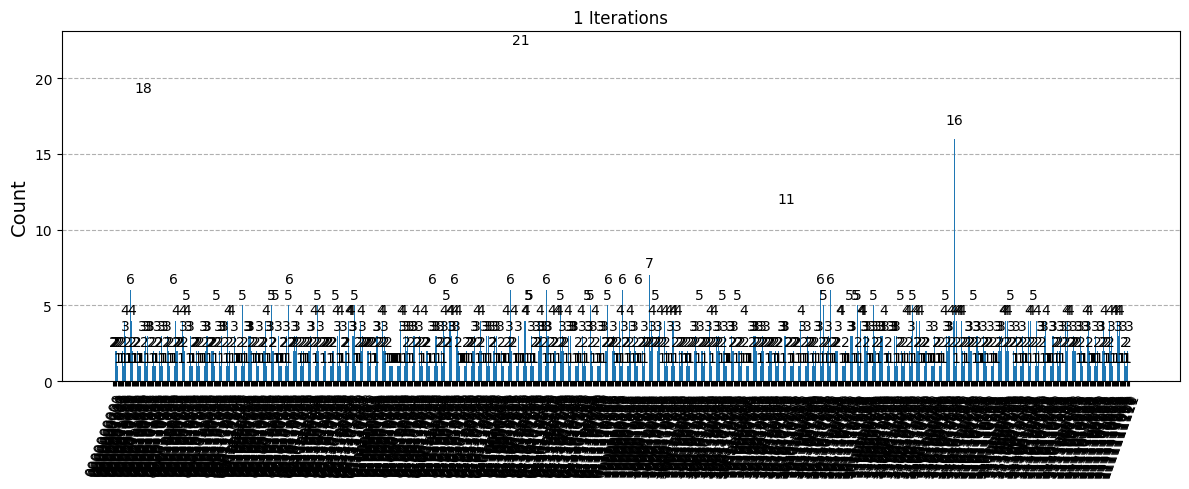

--- 3 Iterations ---


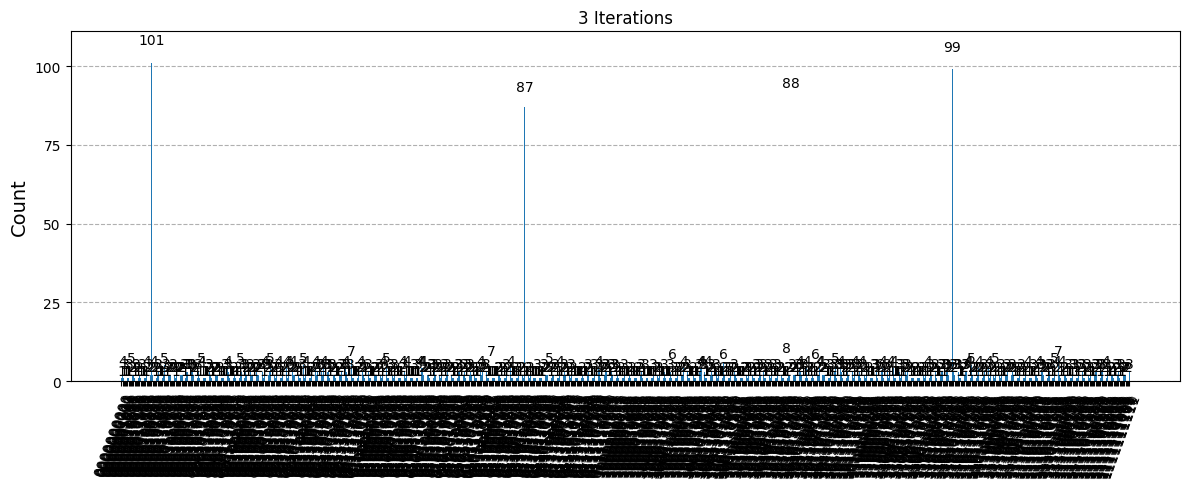

--- 5 Iterations ---


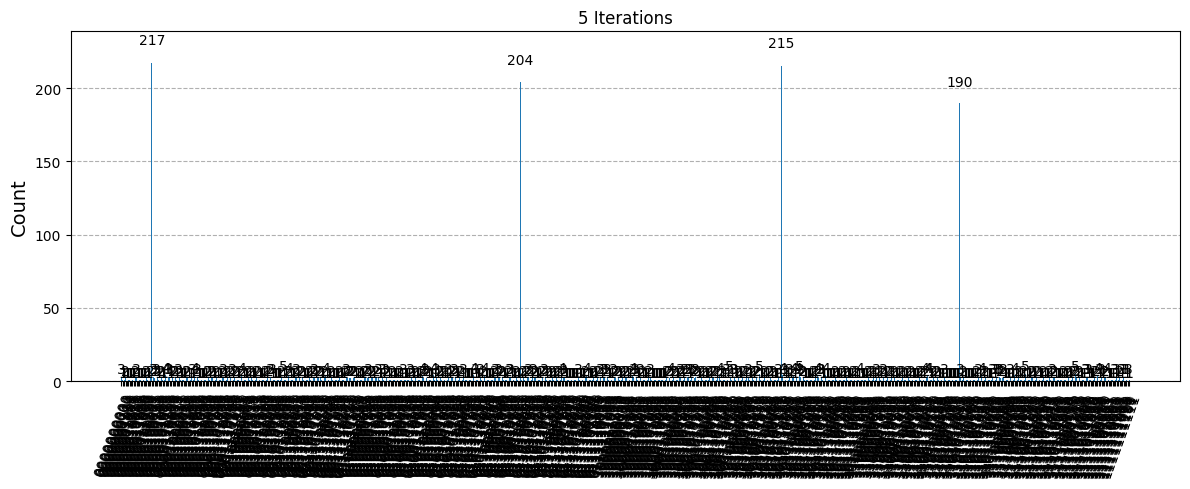

--- 10 Iterations ---


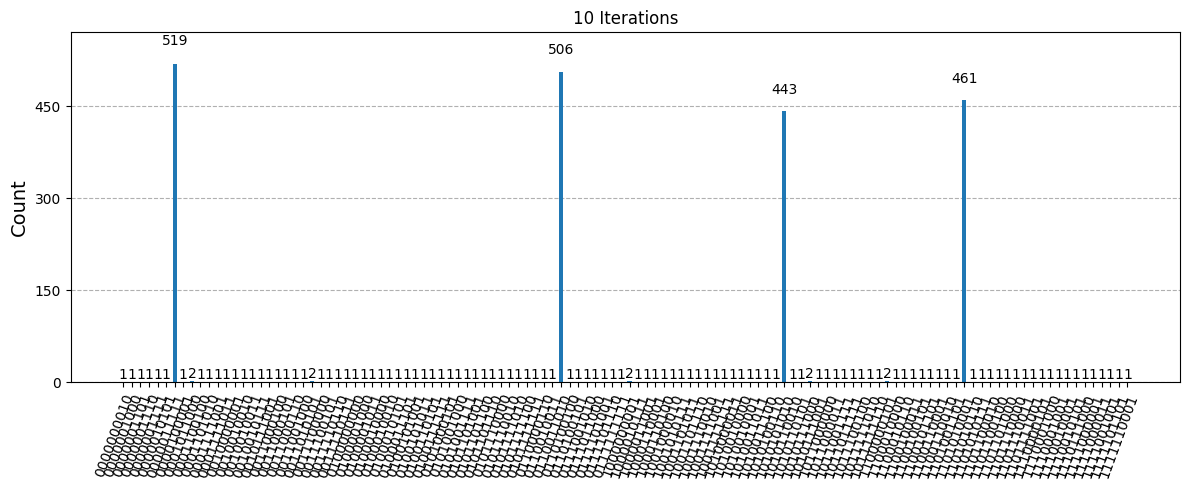

In [18]:
n = 10
# Using the two required states plus two others to solve for >3 targets
targets = ["0110011010", "1101010001", "1010101010", "0000011111"] 
iteration_counts = [1, 3, 5, 10]
results = {}

for count in iteration_counts:
    qr = QuantumRegister(n)
    cr = ClassicalRegister(n)
    qc = QuantumCircuit(qr, cr)
    
    qc.h(range(n)) # Step 1: Superposition [cite: 21]
    
    oracle_gate = create_oracle(targets, n)
    diffusion_gate = create_diffusion(n)
    
    for _ in range(count):
        qc.append(oracle_gate, range(n))
        qc.append(diffusion_gate, range(n))
    
    qc = qc.decompose() # Essential for the simulator to recognize custom gates
    qc.measure(range(n), range(n))
    
    backend = AerSimulator()
    job = backend.run(qc, shots=2048) # Using > 1024 shots [cite: 36]
    results[f"{count} Iterations"] = job.result().get_counts()

# Displaying the results to observe probability changes 
for label, counts in results.items():
    print(f"--- {label} ---")
    # In a notebook, this will display multiple histograms
    display(plot_histogram(counts, title=label, figsize=(12, 5)))